Analyzing property correlation for containing system: ['Fe', 'O']...



Retrieving SummaryDoc documents:   0%|          | 0/477 [00:00<?, ?it/s]

Retrieved 477 stable materials.
Correlation coefficient (r) between density and molar mass: 0.098



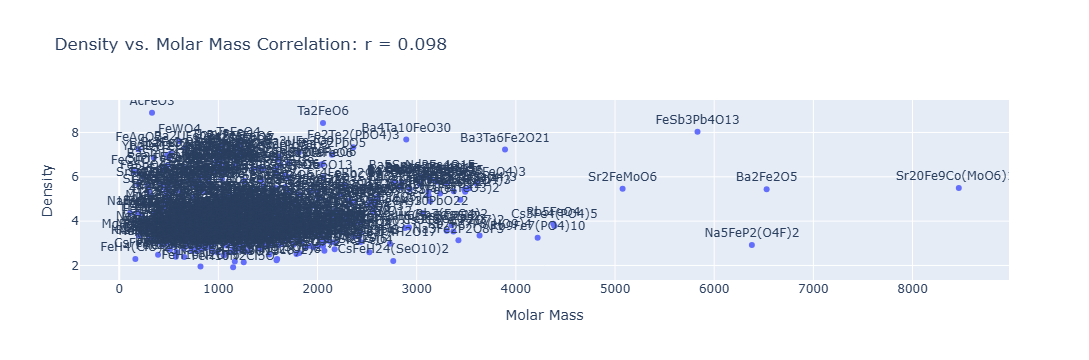

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from mp_api.client import MPRester
import plotly.express as px
import numpy as np
import warnings
warnings.filterwarnings('ignore')

API_KEY = "YOUR_API_KEY_HERE"  # Replace with your Materials Project API key

def plot_density_vs_molar_mass(elements, exact_match=True):
    
    # For a given element list (e.g. ["Fe", "C"]), plot Density vs. Molar Mass and compute the correlation coefficient.
    # If exact_match is True, returns only materials with exactly that composition. If False, returns materials that contain those elements.
    
    print(f"Analyzing property correlation for {'exact' if exact_match else 'containing'} system: {elements}...\n")

    with MPRester(API_KEY) as mpr:
        if exact_match:
            chemsys = "-".join(sorted(elements))
            docs = mpr.materials.summary.search(
                chemsys=chemsys,
                is_stable=True,
                fields=["material_id", "formula_pretty", "density", "composition"]
            )
        else:
            docs = mpr.materials.summary.search(
                elements=elements,
                is_stable=True,
                fields=["material_id", "formula_pretty", "density", "composition"]
            )

    # Extract the data from materials project database
    data = []
    for doc in docs:
        try:
            formula = doc.formula_pretty
            density = doc.density
            molar_mass = doc.composition.weight

            if density is not None:
                data.append({
                    "Formula": formula,
                    "Density": density,
                    "Molar Mass": molar_mass
                })
        except Exception:
            continue

    df = pd.DataFrame(data)

    if df.empty:
        print("❌ No stable materials found for this system. Try different elements or set exact_match=False.")
        return

    print(f"Retrieved {len(df)} stable materials.")

    # This correlates both properties
    corr = df["Density"].corr(df["Molar Mass"])
    print(f"Correlation coefficient (r) between density and molar mass: {corr:.3f}\n")

    # Creates a scatter plot of Density vs. Molar Mass.
    fig = px.scatter(
        df,
        x="Molar Mass",
        y="Density",
        text="Formula",
        title=f"Density vs. Molar Mass\nCorrelation: r = {corr:.3f}"
    )
    fig.update_traces(textposition='top center')
    fig.show()

    return df

if __name__ == "__main__":
    # Change the "Fe" and "O" to whatever 2 elements you want.
    #If you want only those 2 elements, set exact match to "True". Otherwise, set it to "False"
    plot_density_vs_molar_mass(["Fe", "O"], exact_match=False)